In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
#| output: false

%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-cpu==2.21.0 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow-cpu==2.21.0


# 🧠 Étape 5 : Modélisation — Modèle Unifié de Succès Musical

Cette étape remplace l'approche multi-modèles (double moteur + CNN) par un **modèle unique et cohérent** : prédire le **rang relatif d'un morceau dans son genre** à l'aide de 3 nouvelles features construites sur les données existantes.

**Angle retenu :** Combiner la réputation de l'artiste, la distance au profil audio du genre, et le rang relatif comme cible — pour identifier ensuite les anomalies de succès que l'audio seul ne peut pas expliquer.

### 1. Préparation de l'environnement

In [2]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

df = pd.read_csv('../data/processed/cleaned_data_sample.csv')
print(f"Dataset chargé : {df.shape[0]:,} morceaux × {df.shape[1]} colonnes")
print(f"Colonnes disponibles : {list(df.columns)}")

Dataset chargé : 97,270 morceaux × 21 colonnes
Colonnes disponibles : ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


### 2. Feature Engineering — Les 3 nouvelles variables

Au lieu d'utiliser uniquement les 9 features audio brutes (qui corrèlent faiblement avec la popularité), on construit 3 variables qui capturent des signaux bien plus riches :

| Feature | Ce qu'elle mesure | Pourquoi c'est pertinent |
|---|---|---|
| `artist_reputation` | Popularité moyenne de l'artiste sur tout son catalogue | Un artiste établi tire ses morceaux vers le haut |
| `pop_rank_in_genre` | Rang percentile dans le genre (0=pire, 1=meilleur) — **c'est la cible** | Normalise par rapport à la compétition réelle du morceau |
| `genre_distance` | Distance euclidienne au centroïde audio du genre | Est-ce que ce morceau ressemble à son genre ou est-il atypique ? |

In [3]:
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

# Feature 1 : Réputation artiste — popularité moyenne de l'artiste dans le dataset
df['artist_reputation'] = df.groupby('artists')['popularity'].transform('mean')

# Feature 2 : Rang relatif dans le genre (0 = pire du genre, 1 = meilleur du genre)
df['pop_rank_in_genre'] = df.groupby('track_genre')['popularity'].transform(
    lambda x: x.rank(pct=True)
)

# Feature 3 : Distance au profil audio moyen du genre (normalisé via StandardScaler)
scaler = StandardScaler()
audio_scaled = scaler.fit_transform(df[AUDIO_FEATURES])
audio_scaled_df = pd.DataFrame(audio_scaled, columns=AUDIO_FEATURES, index=df.index)
audio_scaled_df['track_genre'] = df['track_genre'].values
genre_centroids = audio_scaled_df.groupby('track_genre')[AUDIO_FEATURES].mean()
centroid_matrix = np.array([genre_centroids.loc[g].values for g in df['track_genre']])
df['genre_distance'] = np.linalg.norm(audio_scaled - centroid_matrix, axis=1)

# Features classiques supplémentaires
df['duration_min'] = df['duration_ms'] / 60000
df['explicit_int']  = df['explicit'].astype(int)

MODEL_FEATURES = AUDIO_FEATURES + ['artist_reputation', 'genre_distance', 'duration_min', 'explicit_int']
TARGET = 'pop_rank_in_genre'

print("3 nouvelles features créées :")
print(f"  artist_reputation : mean={df['artist_reputation'].mean():.1f} | min={df['artist_reputation'].min():.1f} | max={df['artist_reputation'].max():.1f}")
print(f"  pop_rank_in_genre : mean={df['pop_rank_in_genre'].mean():.3f} (cible normalisée 0-1)")
print(f"  genre_distance    : mean={df['genre_distance'].mean():.3f} | max={df['genre_distance'].max():.3f}")
print(f"\n→ {len(MODEL_FEATURES)} features au total pour le modèle")

3 nouvelles features créées :
  artist_reputation : mean=38.7 | min=1.0 | max=100.0
  pop_rank_in_genre : mean=0.501 (cible normalisée 0-1)
  genre_distance    : mean=2.240 | max=8.904

→ 13 features au total pour le modèle


### 3. Entraînement du Modèle Unifié

Un seul **RandomForestRegressor** entraîné sur le rang relatif par genre. Avantages de cette cible :
- Compare un morceau à **sa vraie concurrence** (les autres morceaux du même genre)
- Élimine le biais structurel des genres "naturellement" plus populaires (Pop vs Classical)
- Rend les résidus plus interprétables pour l'analyse des anomalies

In [ ]:
X = df[MODEL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {len(X_train):,} morceaux | Test : {len(X_test):,} morceaux")

rf = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\nPerformance du Modèle Unifié (cible = rang relatif 0-1 par genre) :")
print(f"  MAE  : {mae:.4f}  (erreur moyenne de ±{mae:.3f} rang sur 0-1)")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.3f}  →  {r2*100:.1f}% de la variance expliquée")
print(f"\n  Rappel ancien modèle (popularité brute) : R² = 0.446")

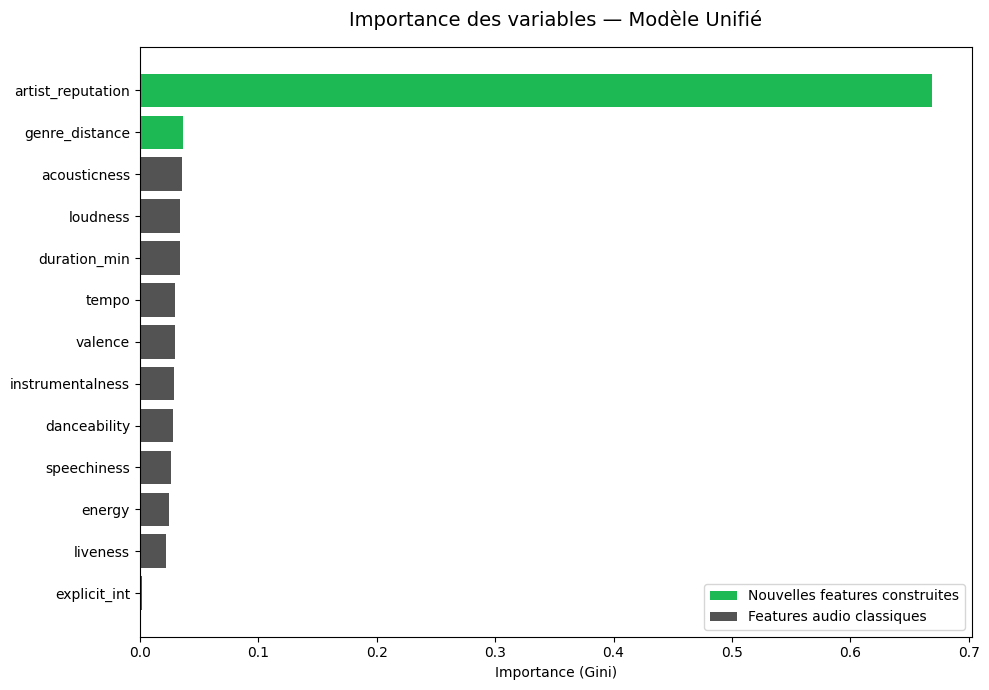

In [5]:
importances = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

colors = [
    '#1DB954' if f in ['artist_reputation', 'genre_distance'] else '#535353'
    for f in importances['feature']
]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importances['feature'], importances['importance'], color=colors)
ax.set_title("Importance des variables — Modèle Unifié", fontsize=14, pad=15)
ax.set_xlabel("Importance (Gini)")

legend_elements = [
    Patch(facecolor='#1DB954', label='Nouvelles features construites'),
    Patch(facecolor='#535353', label='Features audio classiques')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

In [6]:
import json

joblib.dump(rf,     '../data/processed/rf_unified_model.pkl')
joblib.dump(scaler, '../data/processed/audio_scaler.pkl')

artifacts = {
    'model_features': MODEL_FEATURES,
    'audio_features': AUDIO_FEATURES,
    'target': TARGET,
    'genre_centroids': genre_centroids.to_dict(),
    'genres_list': sorted(df['track_genre'].unique().tolist())
}
with open('../data/processed/model_artifacts.json', 'w') as f:
    json.dump(artifacts, f, indent=2)

print("Modèle unifié sauvegardé   : data/processed/rf_unified_model.pkl")
print("Scaler audio sauvegardé    : data/processed/audio_scaler.pkl")
print("Artefacts sauvegardés      : data/processed/model_artifacts.json")

Modèle unifié sauvegardé   : data/processed/rf_unified_model.pkl
Scaler audio sauvegardé    : data/processed/audio_scaler.pkl
Artefacts sauvegardés      : data/processed/model_artifacts.json
